In [18]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
from scipy.signal import detrend
from IPython.display import display


In [19]:
CSV_PATH = r"C:\Users\ADMIN USER\Downloads\EMG-data.csv\EMG-data.csv"       
FS = 1000                  
CLASS_COL = "class"
CHANNEL_COLS = [f"channel{i}" for i in range(1, 9)]

SELECTED_CLASS = 0                     
SELECTED_CH_IDX = 0                     

BANDPASS_LOW = 20                    
BANDPASS_HIGH = 450                   
NOTCH_FREQ = 50                   
NOTCH_Q = 30

RMS_WINDOW = 50                   
SEG_SIZE = 200                  
SEG_OVERLAP = 100                  
N_SEGS_PLOT = 5
VIS_SECONDS = 2.0                  

VIS_SAMPLES = int(VIS_SECONDS * FS)
CH_NAME = CHANNEL_COLS[SELECTED_CH_IDX]



In [20]:
def plot_before_after(before, after, step_name, unit="Amplitude (V)"):
    n = min(VIS_SAMPLES, len(before), len(after))
    t = np.arange(n) / FS * 1000     

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle(
        f"Step: {step_name}  |  Class {SELECTED_CLASS}  |  {CH_NAME}",
        fontsize=14, fontweight="bold", y=1.02
    )

    ax1.plot(t, before[:n], linewidth=0.9)
    ax1.set_title(f"Before {step_name}", fontsize=12)
    ax1.set_xlabel("Time (ms)", fontsize=11)
    ax1.set_ylabel(unit, fontsize=11)
    ax1.grid(True, alpha=0.3)

    ax2.plot(t, after[:n], linewidth=0.9)
    ax2.set_title(f"After {step_name}", fontsize=12)
    ax2.set_xlabel("Time (ms)", fontsize=11)
    ax2.set_ylabel(unit, fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    display(fig)                         
    plt.close(fig)



In [21]:
print("Loading EMG-data.csv …  (large file, may take ~10–20 sec)")
df = pd.read_csv(CSV_PATH)

print(f"\n Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"Classes found: {sorted(df[CLASS_COL].unique())}")

all_signals = df[CHANNEL_COLS].values.astype(np.float64)  
all_classes = df[CLASS_COL].values

mask = all_classes == SELECTED_CLASS
vis_raw = all_signals[mask]

print(f"\n Selected class {SELECTED_CLASS}: {vis_raw.shape[0]:,} samples  "
      f"≈ {vis_raw.shape[0]/FS:.1f} s of data")
print("\nFirst 5 rows of selected class:")
display(df[df[CLASS_COL] == SELECTED_CLASS][CHANNEL_COLS].head())

Loading EMG-data.csv …  (large file, may take ~10–20 sec)

 Dataset shape: 4,237,907 rows × 11 columns
Columns: ['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5', 'channel6', 'channel7', 'channel8', 'class', 'label']
Classes found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

 Selected class 0: 2,725,157 samples  ≈ 2725.2 s of data

First 5 rows of selected class:


,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8
0,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001
1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001
2,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001
3,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001
4,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001


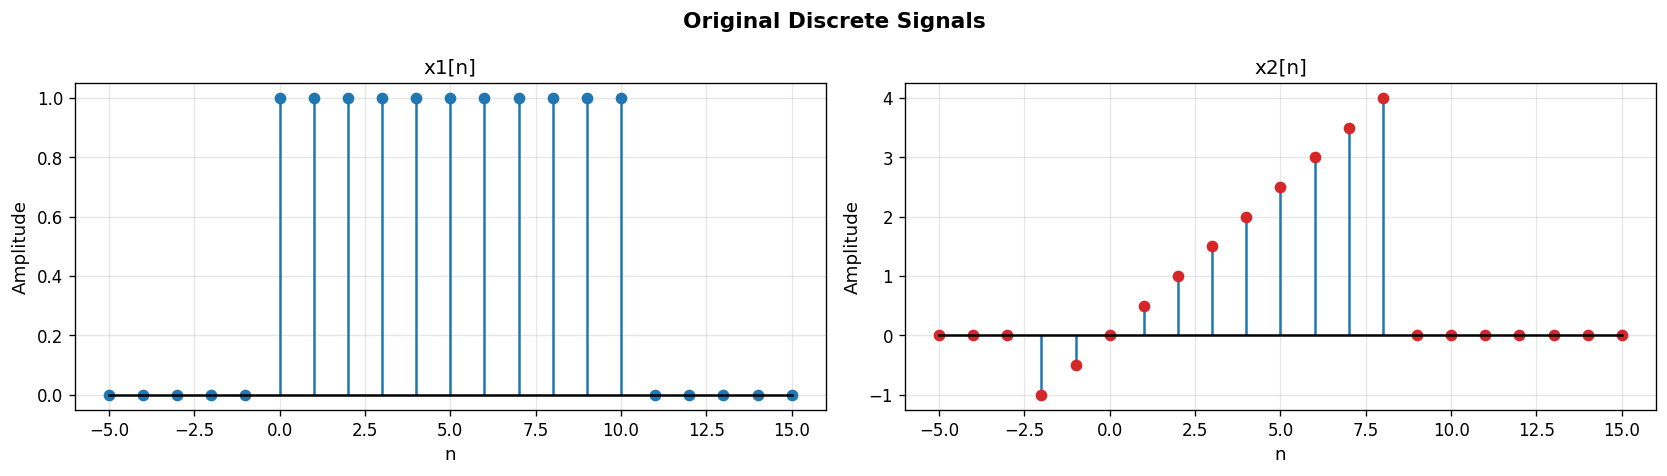

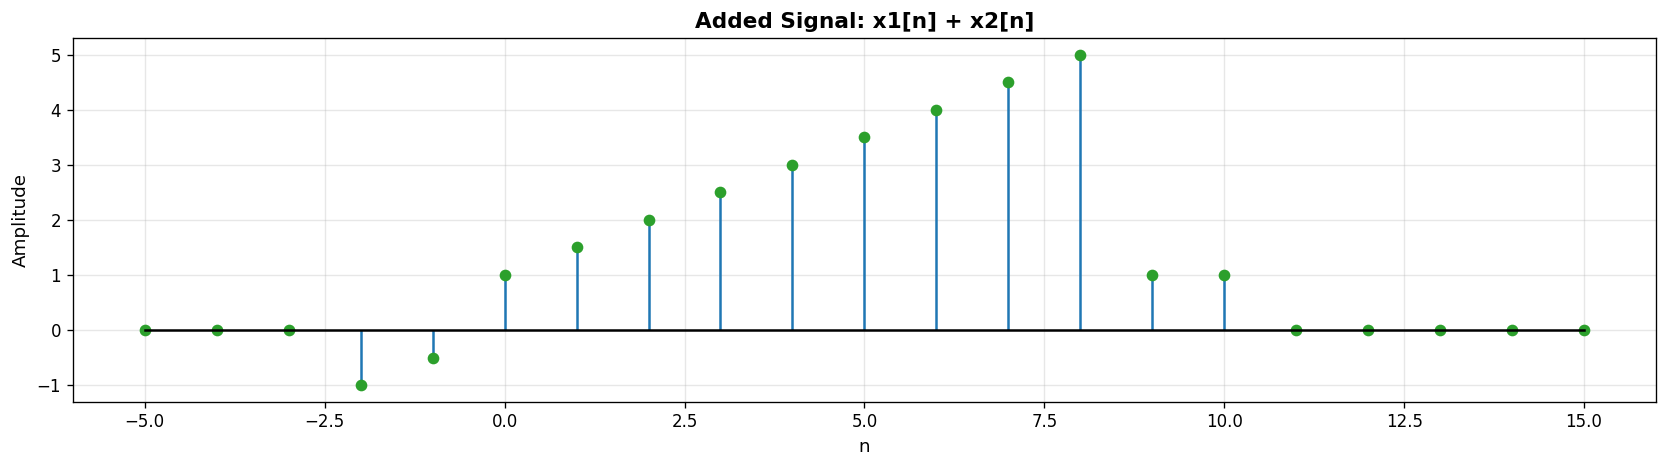

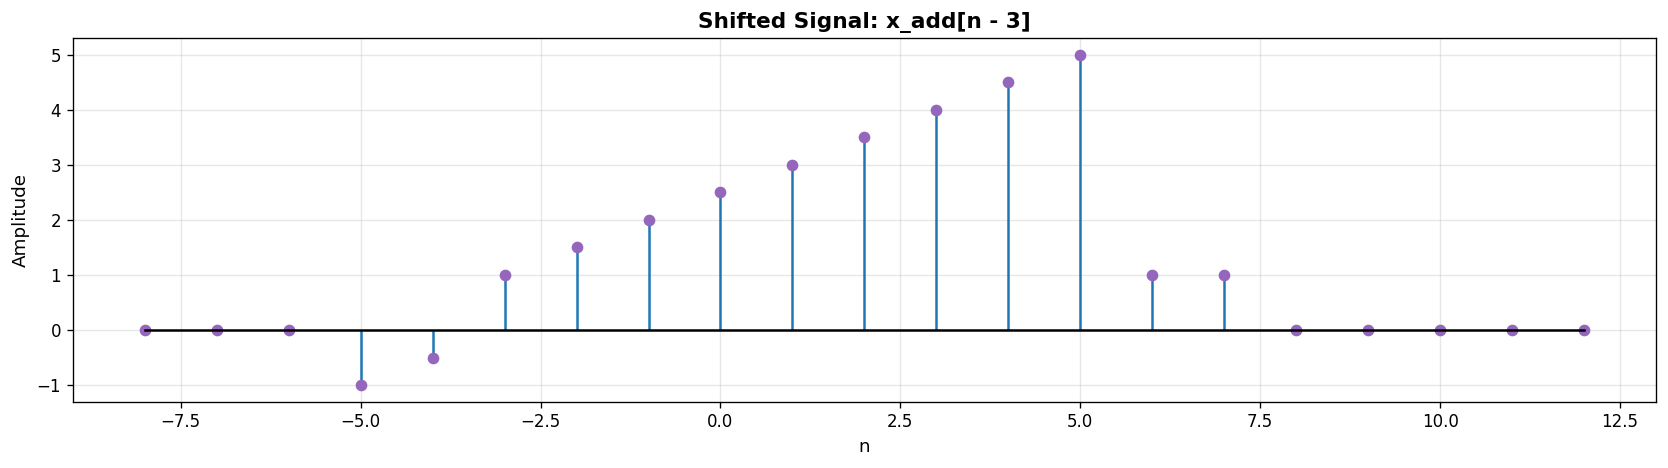

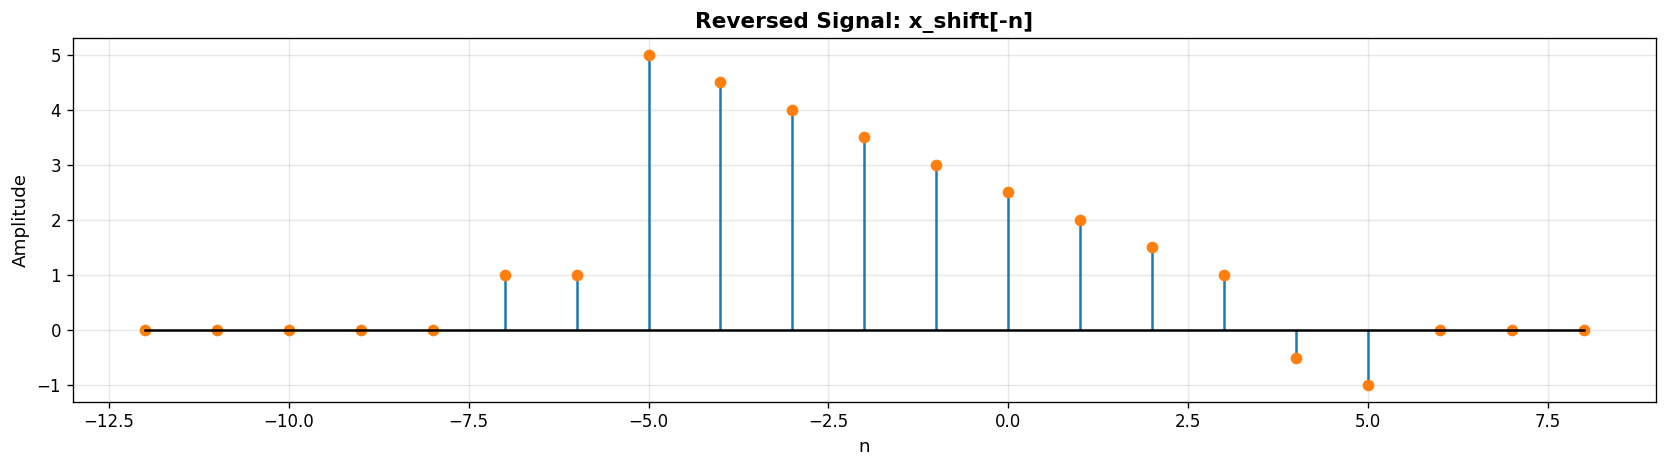

In [22]:
n_d = np.arange(-5, 16)
x1 = np.where((n_d >= 0) & (n_d <= 10), 1.0, 0.0)
x2 = np.where((n_d >= -2) & (n_d <= 8), 0.5 * n_d, 0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Original Discrete Signals", fontsize=13, fontweight="bold")
ax1.stem(n_d, x1,  markerfmt="C0o", basefmt="k-")
ax1.set_title("x1[n]", fontsize=12)
ax1.set_xlabel("n", fontsize=11)
ax1.set_ylabel("Amplitude", fontsize=11)
ax1.grid(True, alpha=0.3)
ax2.stem(n_d, x2,  markerfmt="C3o", basefmt="k-")
ax2.set_title("x2[n]", fontsize=12)
ax2.set_xlabel("n", fontsize=11)
ax2.set_ylabel("Amplitude", fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
plt.close(fig)

x_add = x1 + x2

fig, ax = plt.subplots(figsize=(14, 4))
ax.stem(n_d, x_add, markerfmt="C2o", basefmt="k-")
ax.set_title("Added Signal: x1[n] + x2[n]", fontsize=13, fontweight="bold")
ax.set_xlabel("n", fontsize=11)
ax.set_ylabel("Amplitude", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
plt.close(fig)

shift_k = 3
n_shift = n_d - shift_k
x_shift = x_add.copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.stem(n_shift, x_shift, markerfmt="C4o", basefmt="k-")
ax.set_title(f"Shifted Signal: x_add[n - {shift_k}]", fontsize=13, fontweight="bold")
ax.set_xlabel("n", fontsize=11)
ax.set_ylabel("Amplitude", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
plt.close(fig)

x_rev = x_shift[::-1]
n_rev = -n_shift[::-1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.stem(n_rev, x_rev, markerfmt="C1o", basefmt="k-")
ax.set_title("Reversed Signal: x_shift[-n]", fontsize=13, fontweight="bold")
ax.set_xlabel("n", fontsize=11)
ax.set_ylabel("Amplitude", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
plt.close(fig)

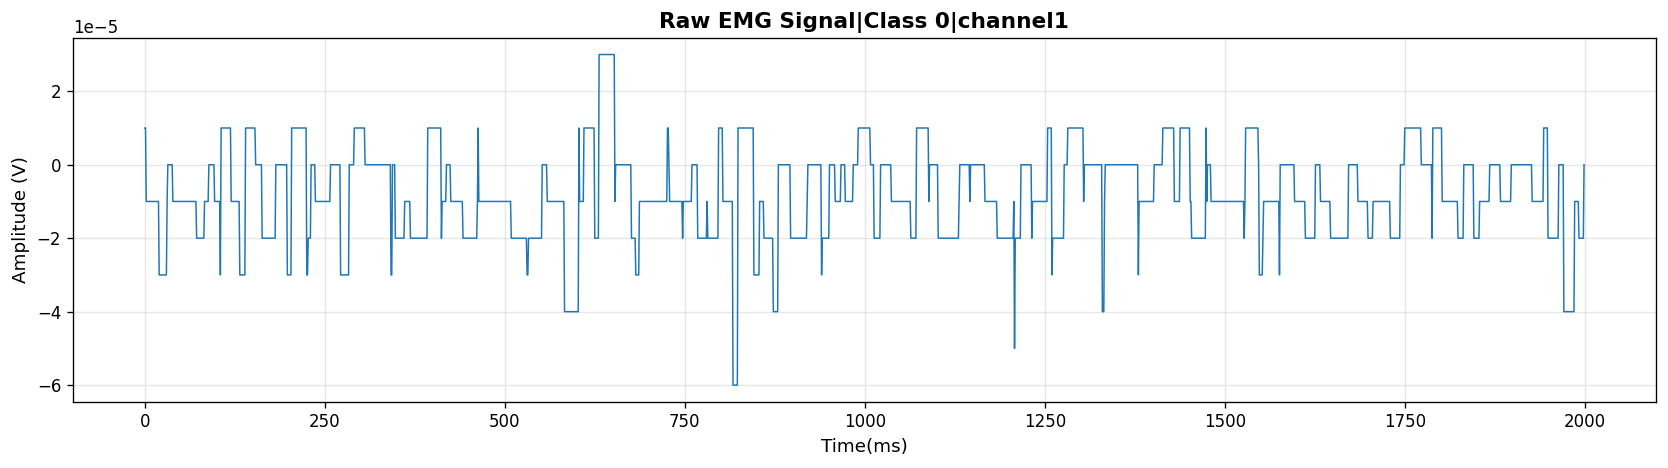

In [23]:
n= min(VIS_SAMPLES, len(vis_raw))
t= np.arange(n)/FS*1000

fig,ax=plt.subplots(figsize=(14, 4))
ax.plot(t, vis_raw[:n, SELECTED_CH_IDX], linewidth=0.9)
ax.set_title(f"Raw EMG Signal|Class {SELECTED_CLASS}|{CH_NAME}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time(ms)",fontsize=11)
ax.set_ylabel("Amplitude (V)",fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
plt.close(fig)


Detrending done | Output shape: (4237907, 8)


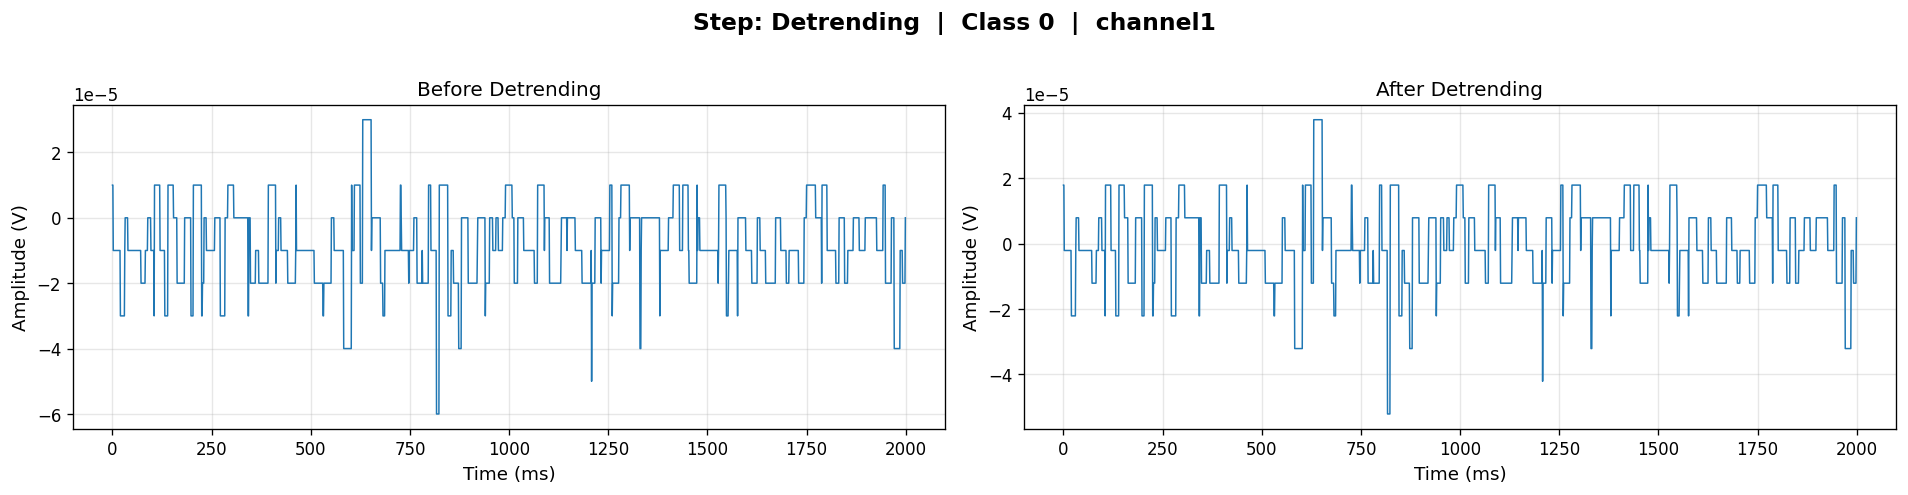

In [24]:

all_detrended = detrend(all_signals, axis=0)
vis_detrended = all_detrended[mask]

print(f"Detrending done | Output shape: {all_detrended.shape}")

plot_before_after(
    vis_raw        [:, SELECTED_CH_IDX],
    vis_detrended  [:, SELECTED_CH_IDX],
    "Detrending"
)


High-pass applied | Output shape: (4237907, 8)


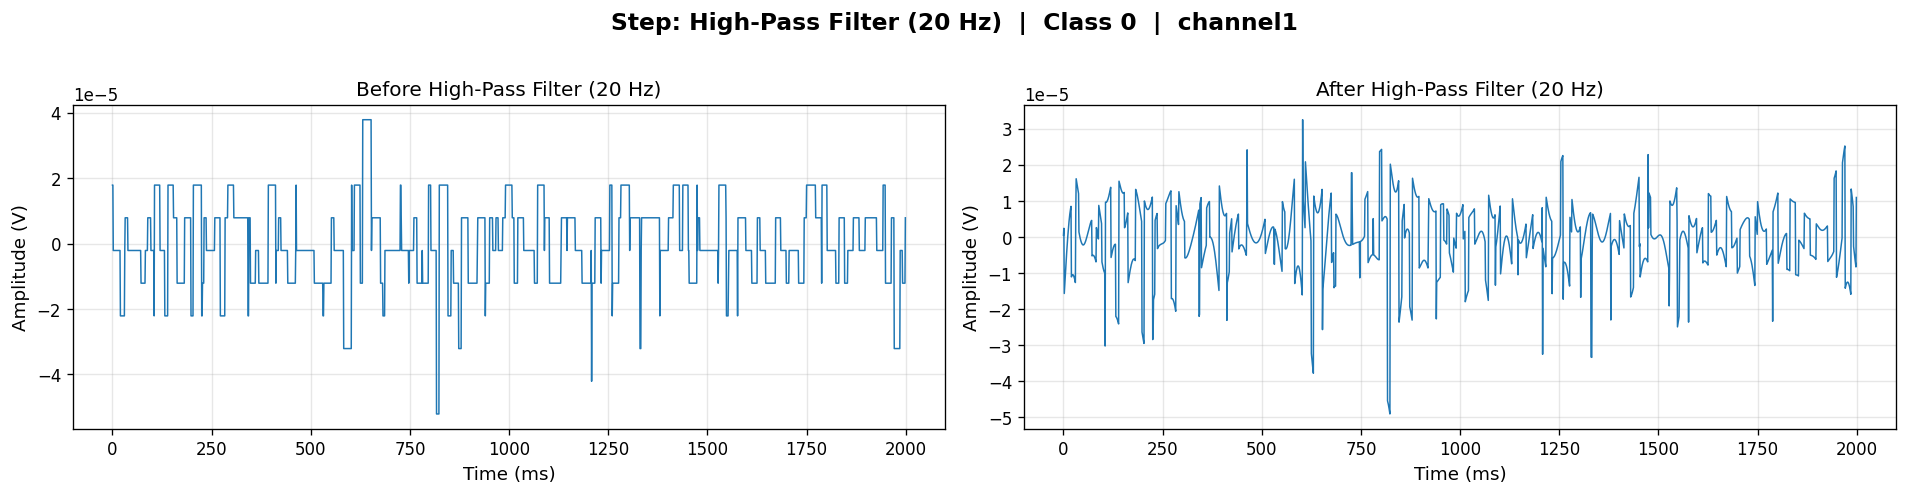

In [25]:

HP_CUTOFF = 20        
nyq = FS / 2.0
b_hp, a_hp = butter(4, HP_CUTOFF / nyq, btype="high")
all_hp = filtfilt(b_hp, a_hp, all_detrended, axis=0)

vis_hp = all_hp[mask]
print(f"High-pass applied | Output shape: {all_hp.shape}")

plot_before_after(
    vis_detrended[:, SELECTED_CH_IDX],
    vis_hp       [:, SELECTED_CH_IDX],
    f"High-Pass Filter ({HP_CUTOFF} Hz)"
)


Bandpass applied | Output shape: (4237907, 8)


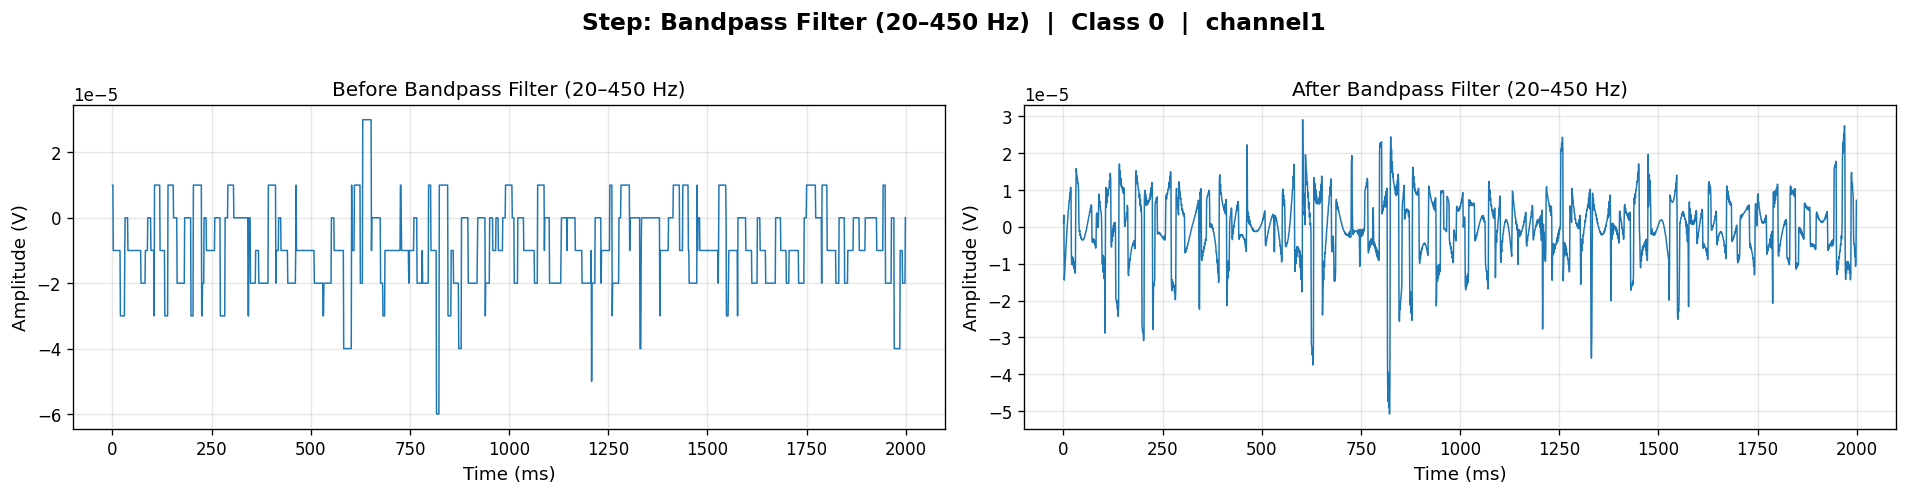

In [26]:
nyq=FS/2.0
b,a =butter(4, [BANDPASS_LOW / nyq, BANDPASS_HIGH / nyq], btype="band")
all_bp =filtfilt(b, a, all_hp, axis=0)

vis_bp =all_bp[mask]
print(f"Bandpass applied | Output shape: {all_bp.shape}")

plot_before_after(
    vis_raw[:, SELECTED_CH_IDX],
    vis_bp [:, SELECTED_CH_IDX],
    "Bandpass Filter (20–450 Hz)"
)

Low-pass applied | Output shape: (4237907, 8)


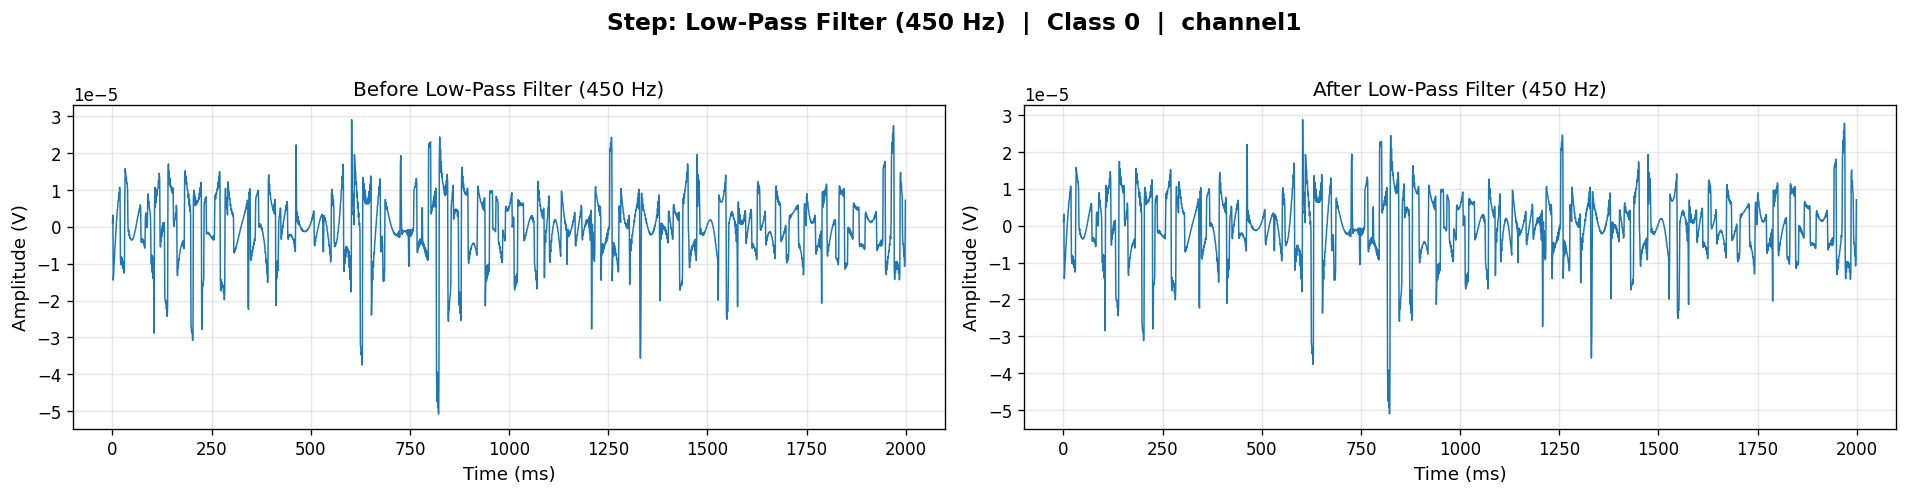

In [27]:

LP_CUTOFF = 450        
b_lp, a_lp = butter(4, LP_CUTOFF / nyq, btype="low")
all_lp = filtfilt(b_lp, a_lp, all_bp, axis=0)

vis_lp = all_lp[mask]
print(f"Low-pass applied | Output shape: {all_lp.shape}")

plot_before_after(
    vis_bp[:, SELECTED_CH_IDX],
    vis_lp[:, SELECTED_CH_IDX],
    f"Low-Pass Filter ({LP_CUTOFF} Hz)"
)


Notch applied | Output shape: (4237907, 8)


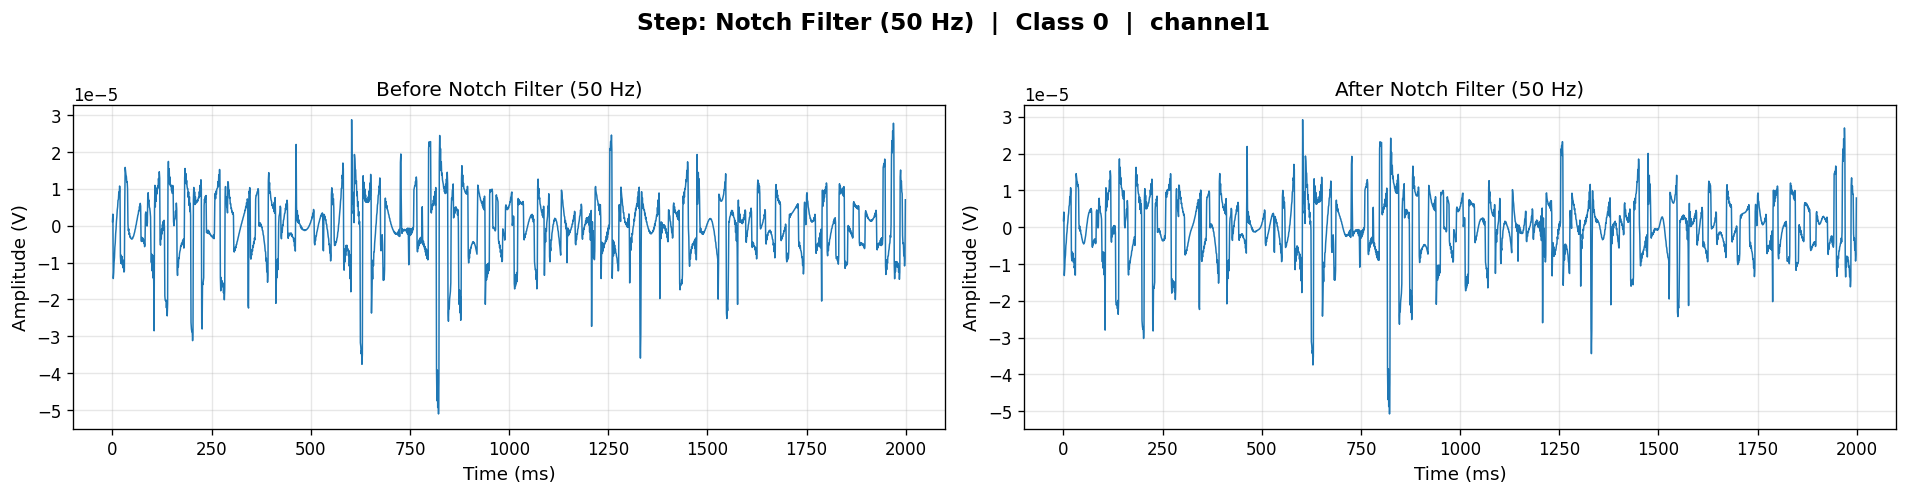

In [28]:

b,a= iirnotch(NOTCH_FREQ/(FS/2.0),NOTCH_Q)
all_notch=filtfilt(b,a,all_lp,axis=0)

vis_notch = all_notch[mask]
print(f"Notch applied | Output shape: {all_notch.shape}")

plot_before_after(
    vis_lp   [:, SELECTED_CH_IDX],
    vis_notch[:, SELECTED_CH_IDX],
    "Notch Filter (50 Hz)"
)

Rectification done | Output shape: (4237907, 8)


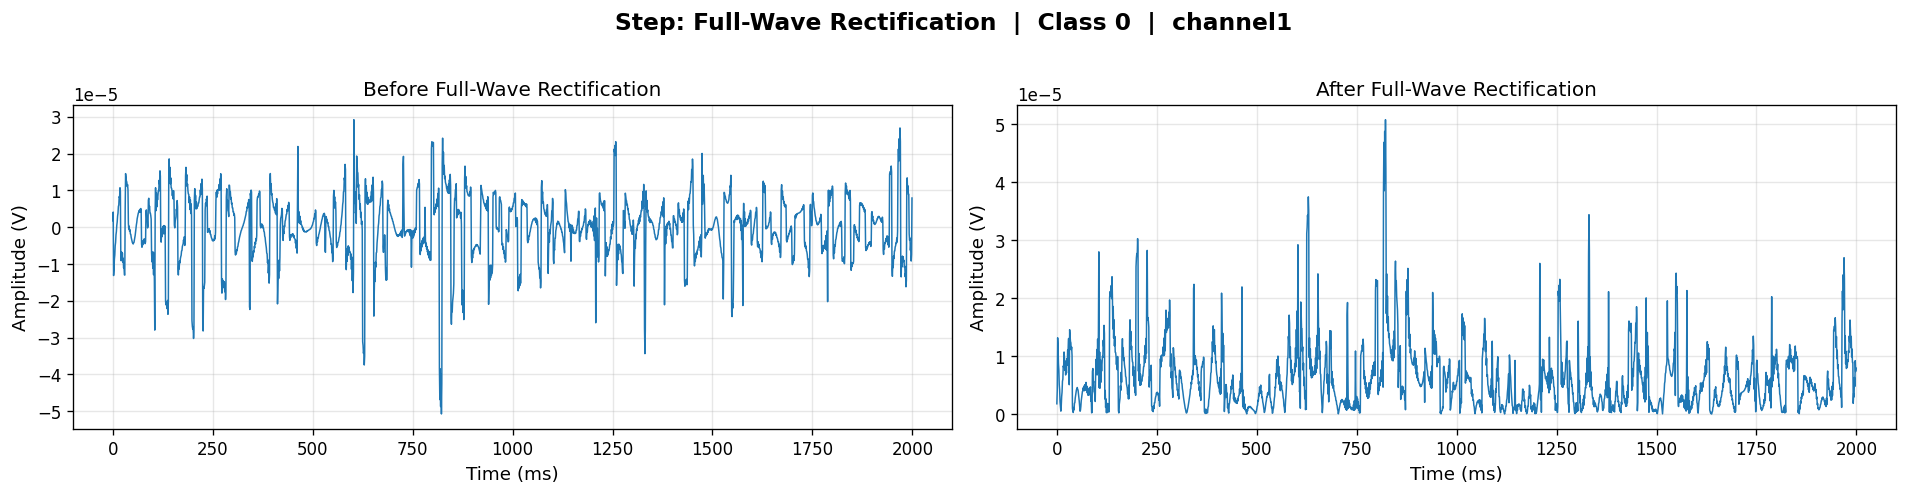

In [29]:

all_rect=np.abs(all_notch)
vis_rect=all_rect[mask]

print(f"Rectification done | Output shape: {all_rect.shape}")

plot_before_after(
    vis_notch[:, SELECTED_CH_IDX],
    vis_rect [:, SELECTED_CH_IDX],
    "Full-Wave Rectification"
)

RMS smoothing done | Output shape: (4237907, 8)


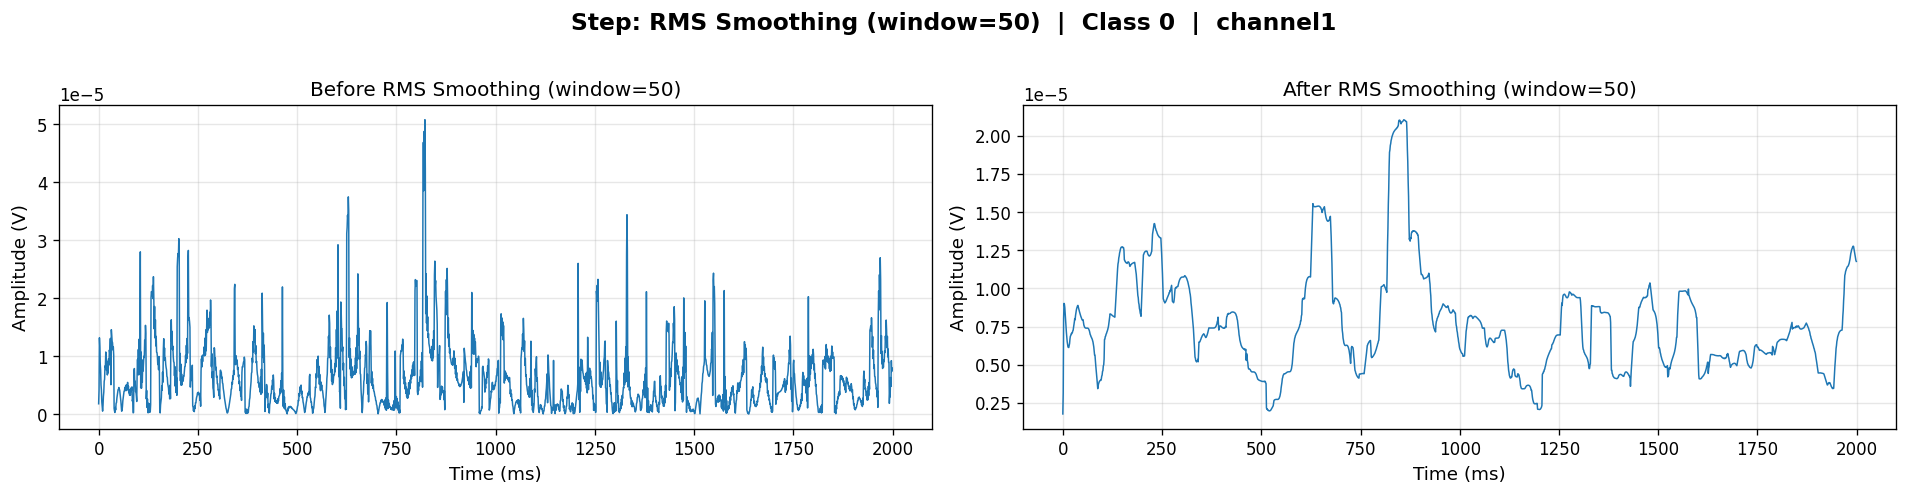

In [30]:
def rms_smooth(signals, window):
    sq=signals ** 2
    cs=np.cumsum(sq, axis=0)
    out=np.zeros_like(signals)
    out[:window]=np.sqrt(cs[:window] /
                           np.arange(1, window + 1).reshape(-1, 1))
    out[window:]=np.sqrt((cs[window:] - cs[:-window]) / window)
    return out

all_rms=rms_smooth(all_rect, RMS_WINDOW)
vis_rms=all_rms[mask]

print(f"RMS smoothing done | Output shape: {all_rms.shape}")

plot_before_after(
    vis_rect[:, SELECTED_CH_IDX],
    vis_rms [:, SELECTED_CH_IDX],
    f"RMS Smoothing (window={RMS_WINDOW})"
)

Normalisation done | Output shape: (4237907, 8)
Value range check min: 0.0000  max: 1.0000


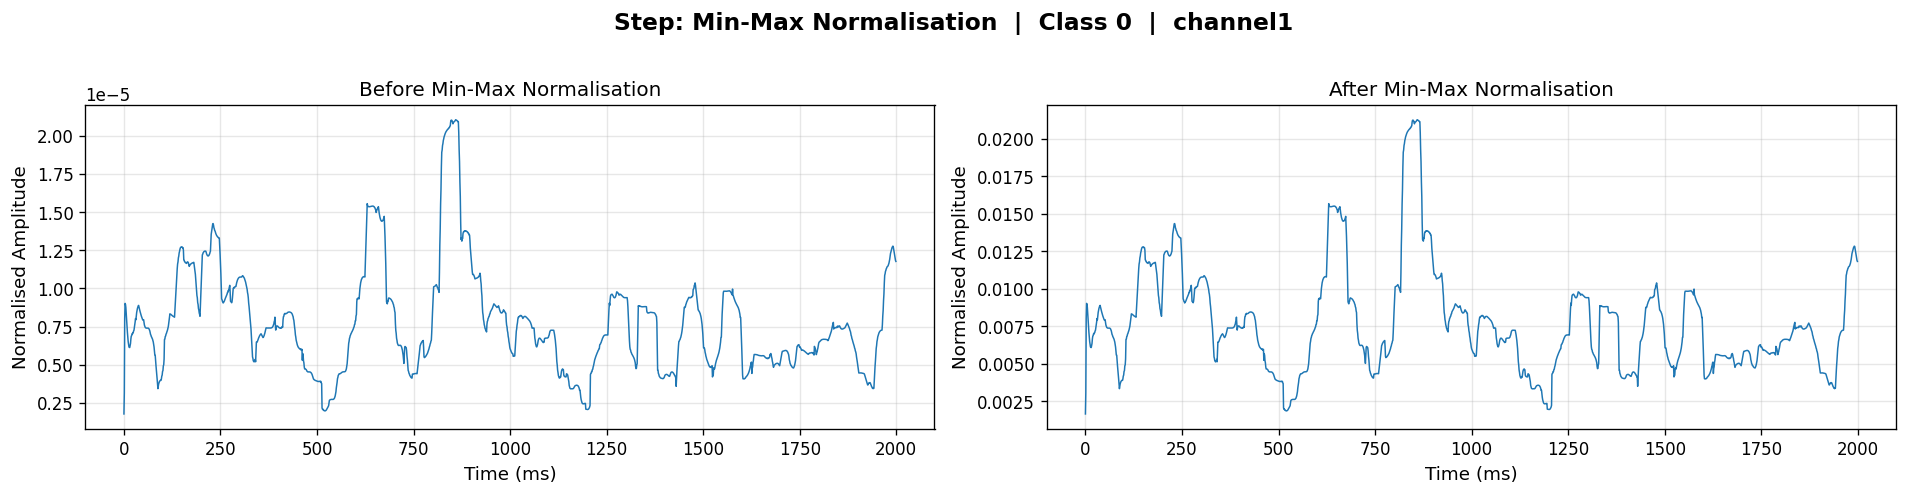

In [31]:
min_v =all_rms.min(axis=0, keepdims=True)
max_v =all_rms.max(axis=0, keepdims=True)
denom =np.where((max_v - min_v) == 0, 1.0, max_v - min_v)
all_norm =(all_rms - min_v) / denom

vis_norm =all_norm[mask]

print(f"Normalisation done | Output shape: {all_norm.shape}")
print(f"Value range check min: {vis_norm.min():.4f}  max: {vis_norm.max():.4f}")

plot_before_after(
    vis_rms [:, SELECTED_CH_IDX],
    vis_norm[:, SELECTED_CH_IDX],
    "Min-Max Normalisation",
    unit="Normalised Amplitude"
)

Class 0: 27250 segments | Segment shape: (200, 8)
Class 1: 2499 segments | Segment shape: (200, 8)
Class 2: 2430 segments | Segment shape: (200, 8)
Class 3: 2493 segments | Segment shape: (200, 8)
Class 4: 2514 segments | Segment shape: (200, 8)
Class 5: 2516 segments | Segment shape: (200, 8)
Class 6: 2529 segments | Segment shape: (200, 8)
Class 7: 135 segments | Segment shape: (200, 8)


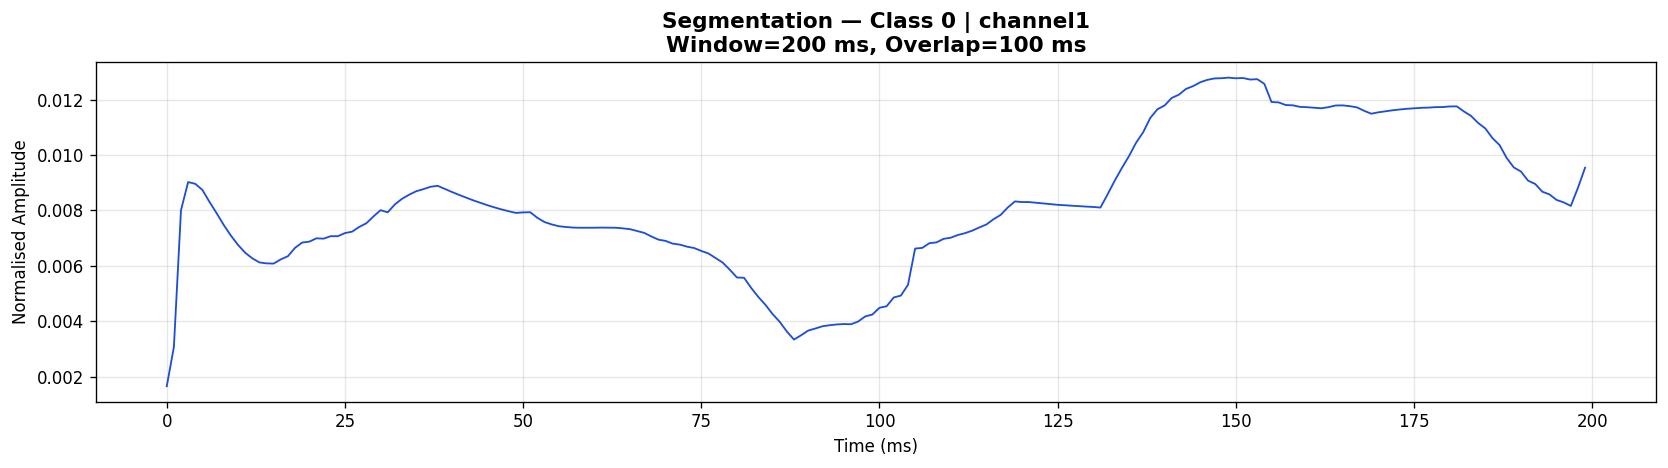

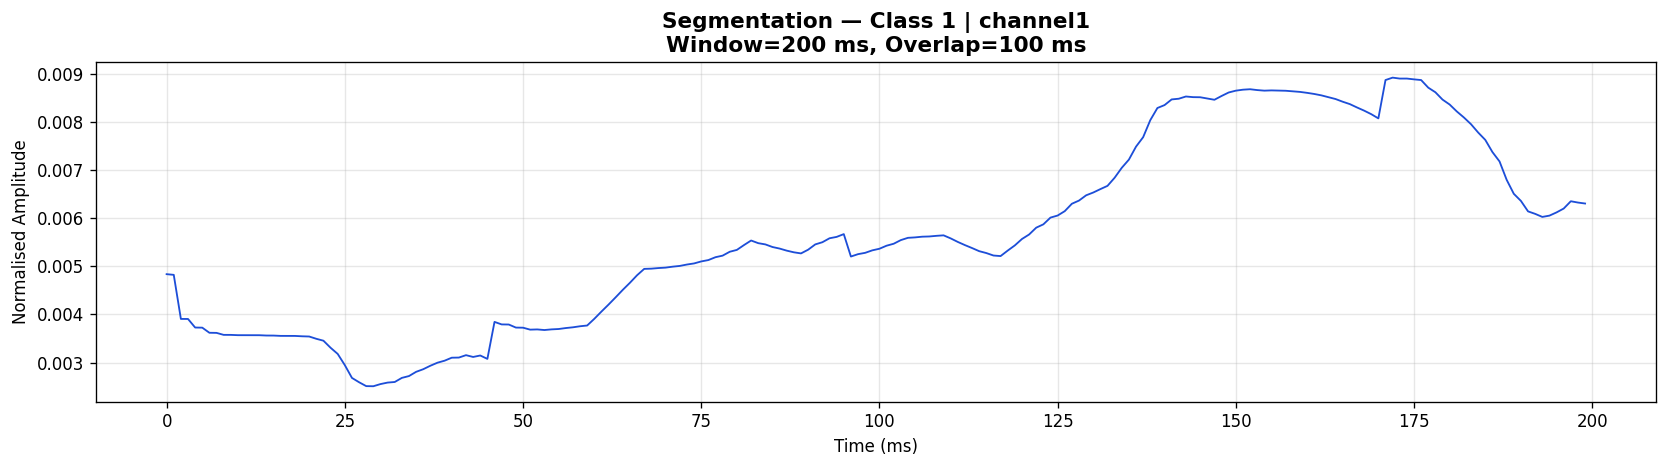

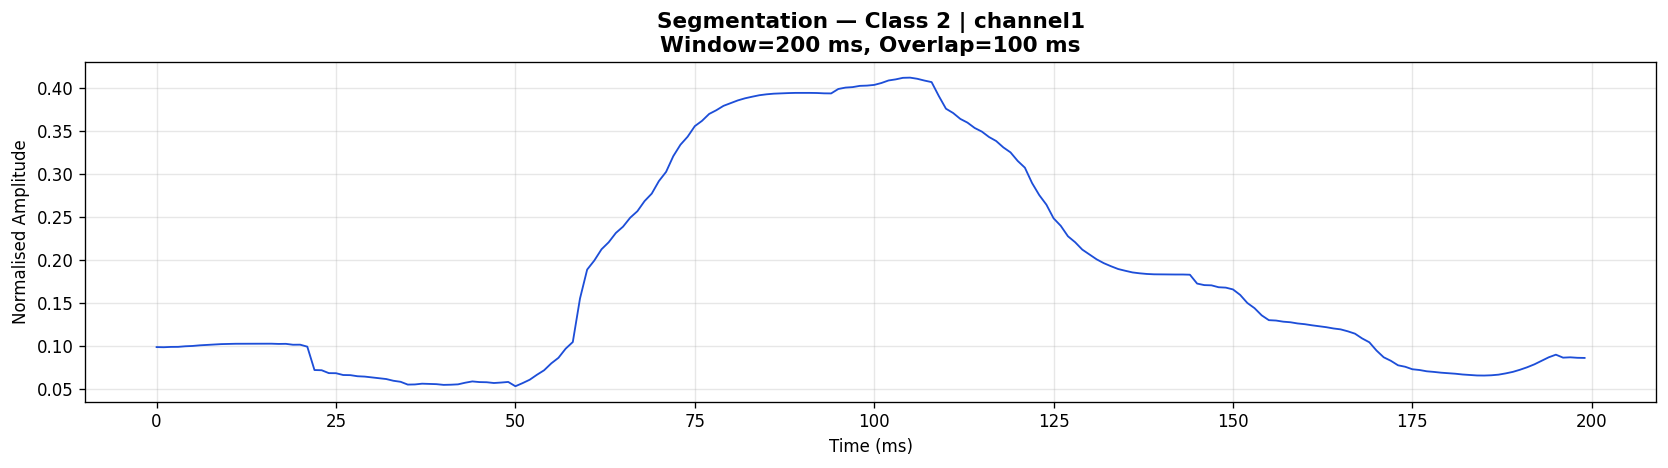

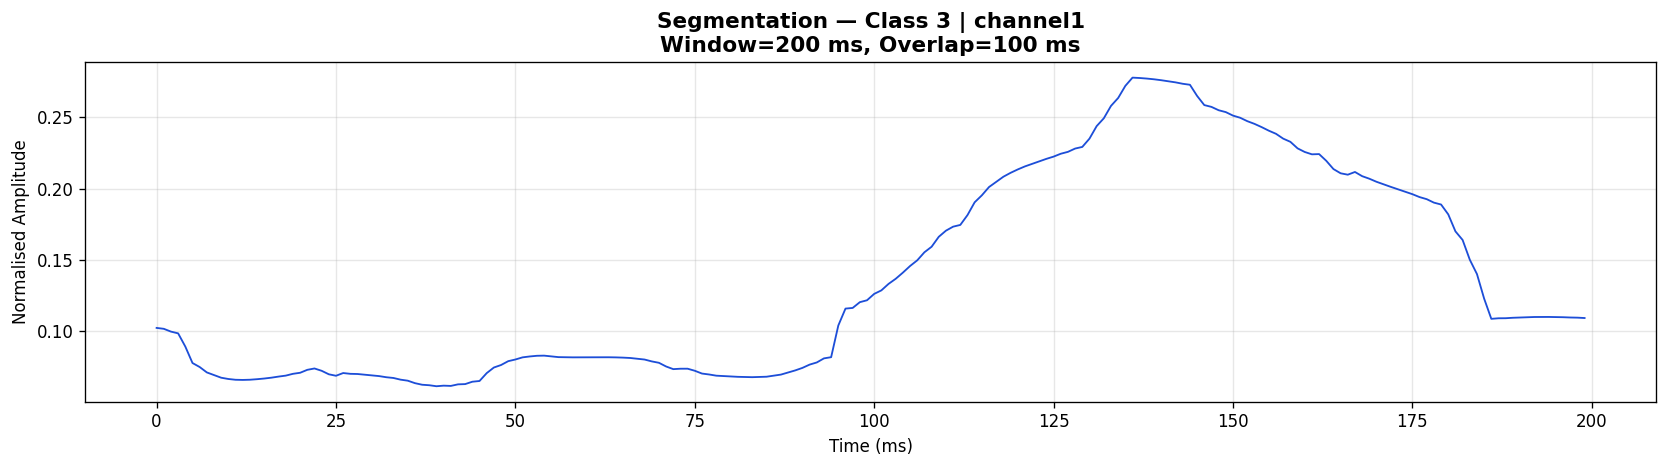

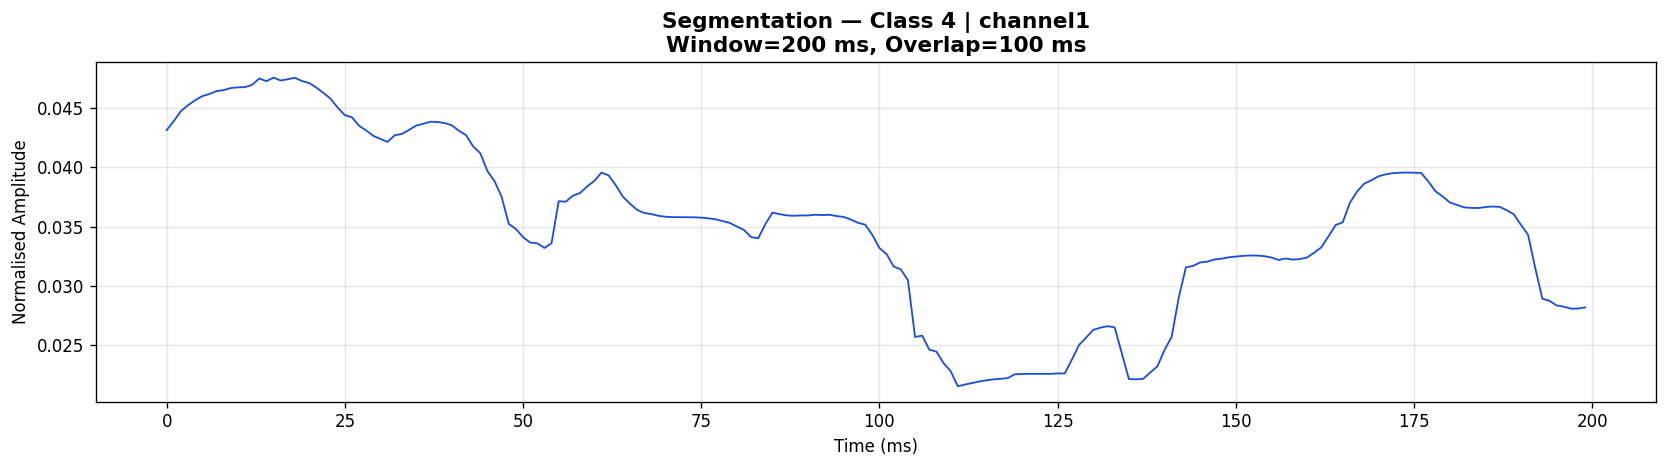

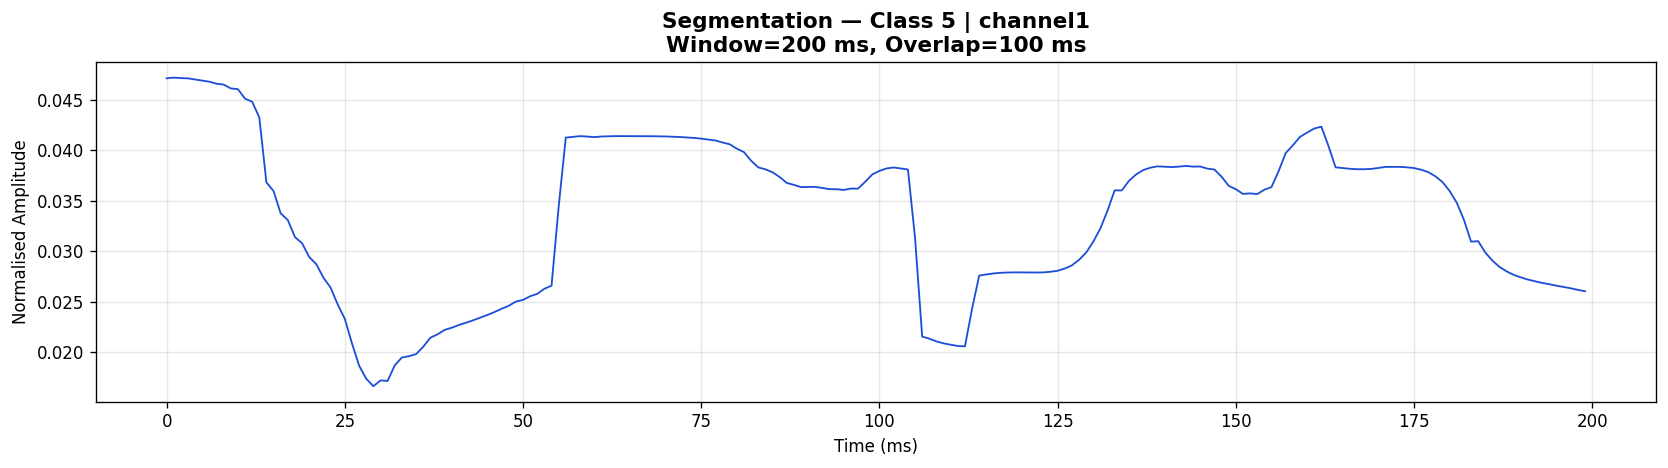

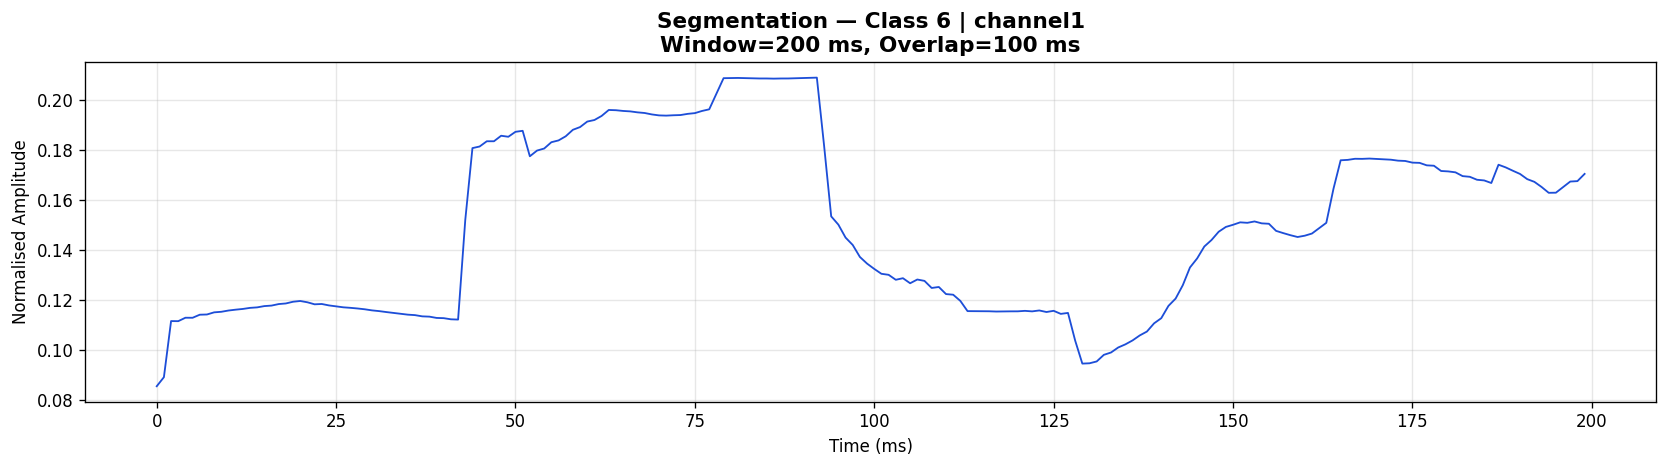

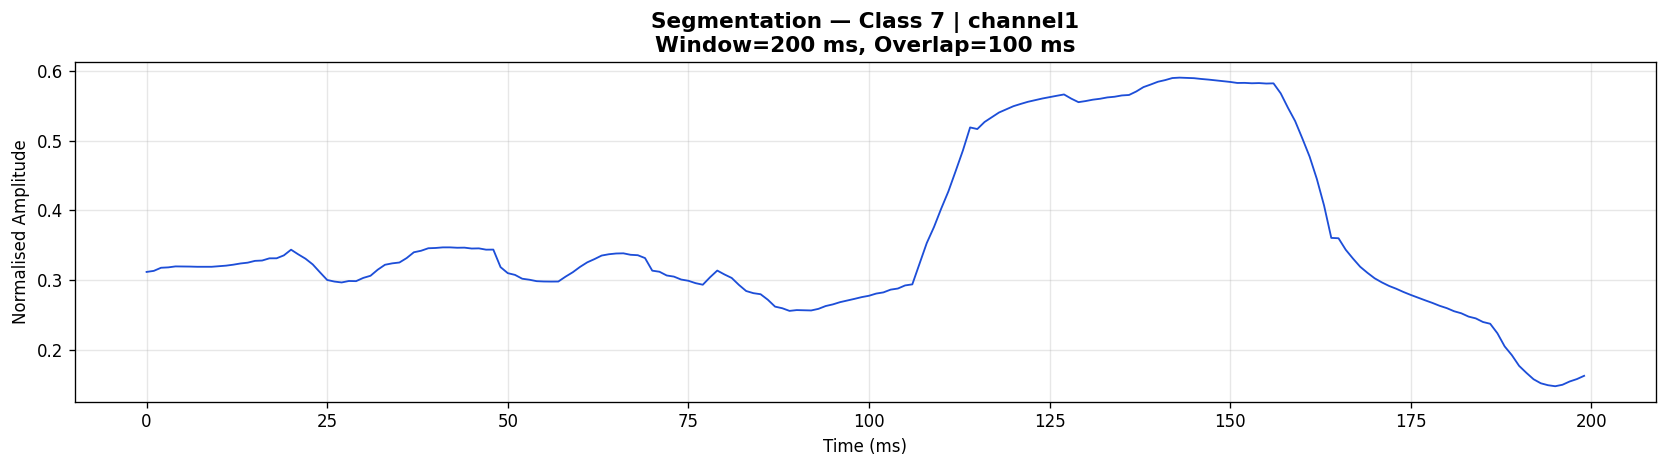

In [32]:
step = SEG_SIZE - SEG_OVERLAP
t_seg = np.arange(SEG_SIZE) / FS * 1000
all_classes_unique = np.unique(all_classes)
segments_by_class = {}

for cls in all_classes_unique:
    cls_mask = all_classes == cls
    cls_norm = all_norm[cls_mask]
    n_total = cls_norm.shape[0]
    segments = []
    start = 0
    while start + SEG_SIZE <= n_total:
        segments.append(cls_norm[start : start + SEG_SIZE, :])
        start += step
    segments_by_class[cls] = segments
    print(f"Class {cls}: {len(segments)} segments | Segment shape: {segments[0].shape}")

for cls in all_classes_unique:
    segments = segments_by_class[cls]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t_seg, segments[0][:, SELECTED_CH_IDX], color="#1D4ED8", linewidth=1.1)
    ax.set_title(
        f"Segmentation — Class {cls} | {CH_NAME}\n"
        f"Window={SEG_SIZE} ms, Overlap={SEG_OVERLAP} ms",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Time (ms)", fontsize=10)
    ax.set_ylabel("Normalised Amplitude", fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

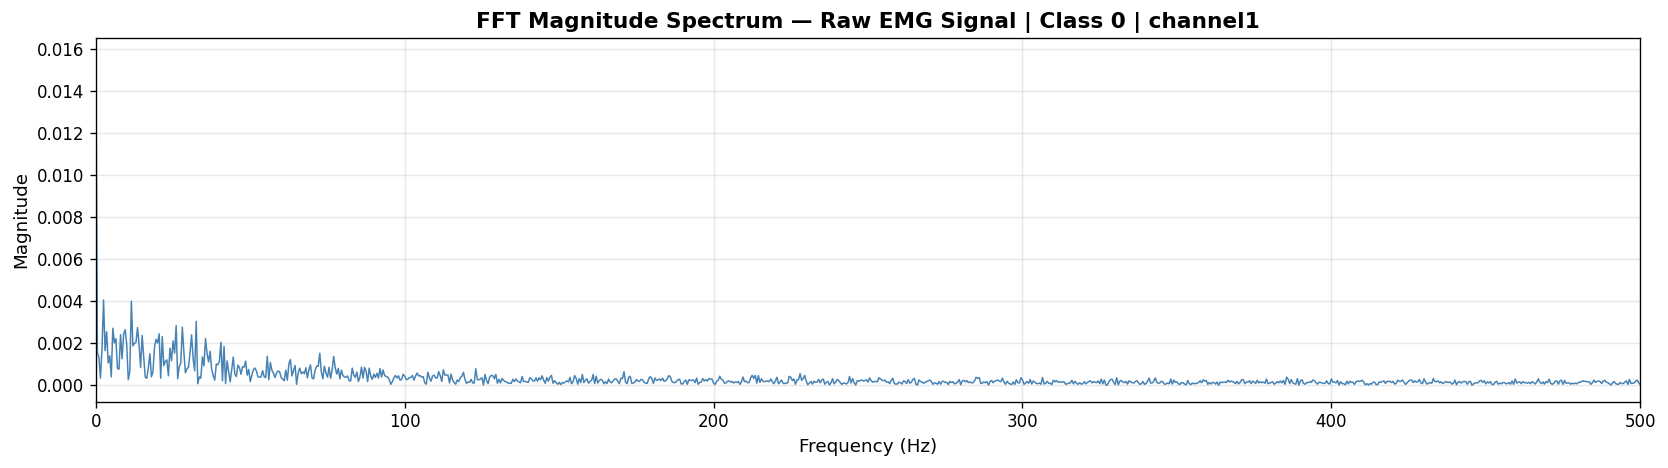

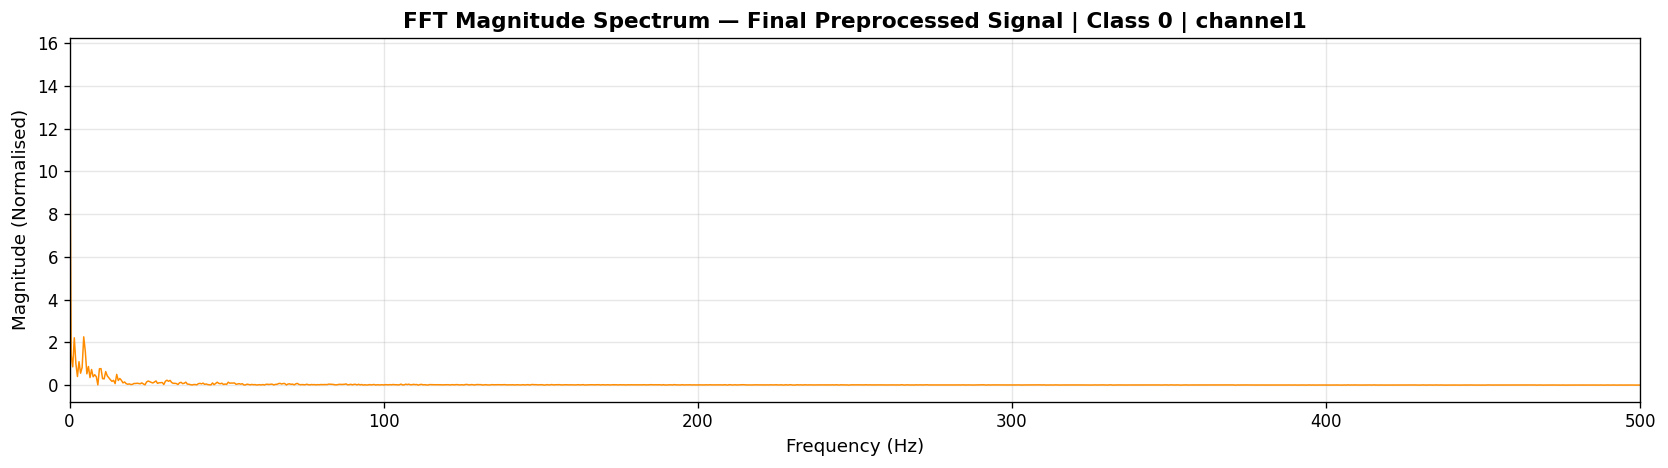

FFT analysis complete.


In [ ]:
n_fft = min(VIS_SAMPLES, vis_raw.shape[0], vis_norm.shape[0])

raw_sig  = vis_raw [:n_fft, SELECTED_CH_IDX]
norm_sig = vis_norm[:n_fft, SELECTED_CH_IDX]

fft_raw  = np.fft.rfft(raw_sig)
fft_norm = np.fft.rfft(norm_sig)
freqs    = np.fft.rfftfreq(n_fft, d=1.0/FS)

mag_raw  = np.abs(fft_raw)
mag_norm = np.abs(fft_norm)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(freqs, mag_raw, linewidth=0.9, color="steelblue")
ax.set_title(f"FFT Magnitude Spectrum — Raw EMG Signal | Class {SELECTED_CLASS} | {CH_NAME}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Frequency (Hz)", fontsize=11)
ax.set_ylabel("Magnitude", fontsize=11)
ax.set_xlim(0, FS / 2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(freqs, mag_norm, linewidth=0.9, color="darkorange")
ax.set_title(f"FFT Magnitude Spectrum — Final Preprocessed Signal | Class {SELECTED_CLASS} | {CH_NAME}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Frequency (Hz)", fontsize=11)
ax.set_ylabel("Magnitude (Normalised)", fontsize=11)
ax.set_xlim(0, FS / 2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
plt.close(fig)

print("FFT analysis complete.")


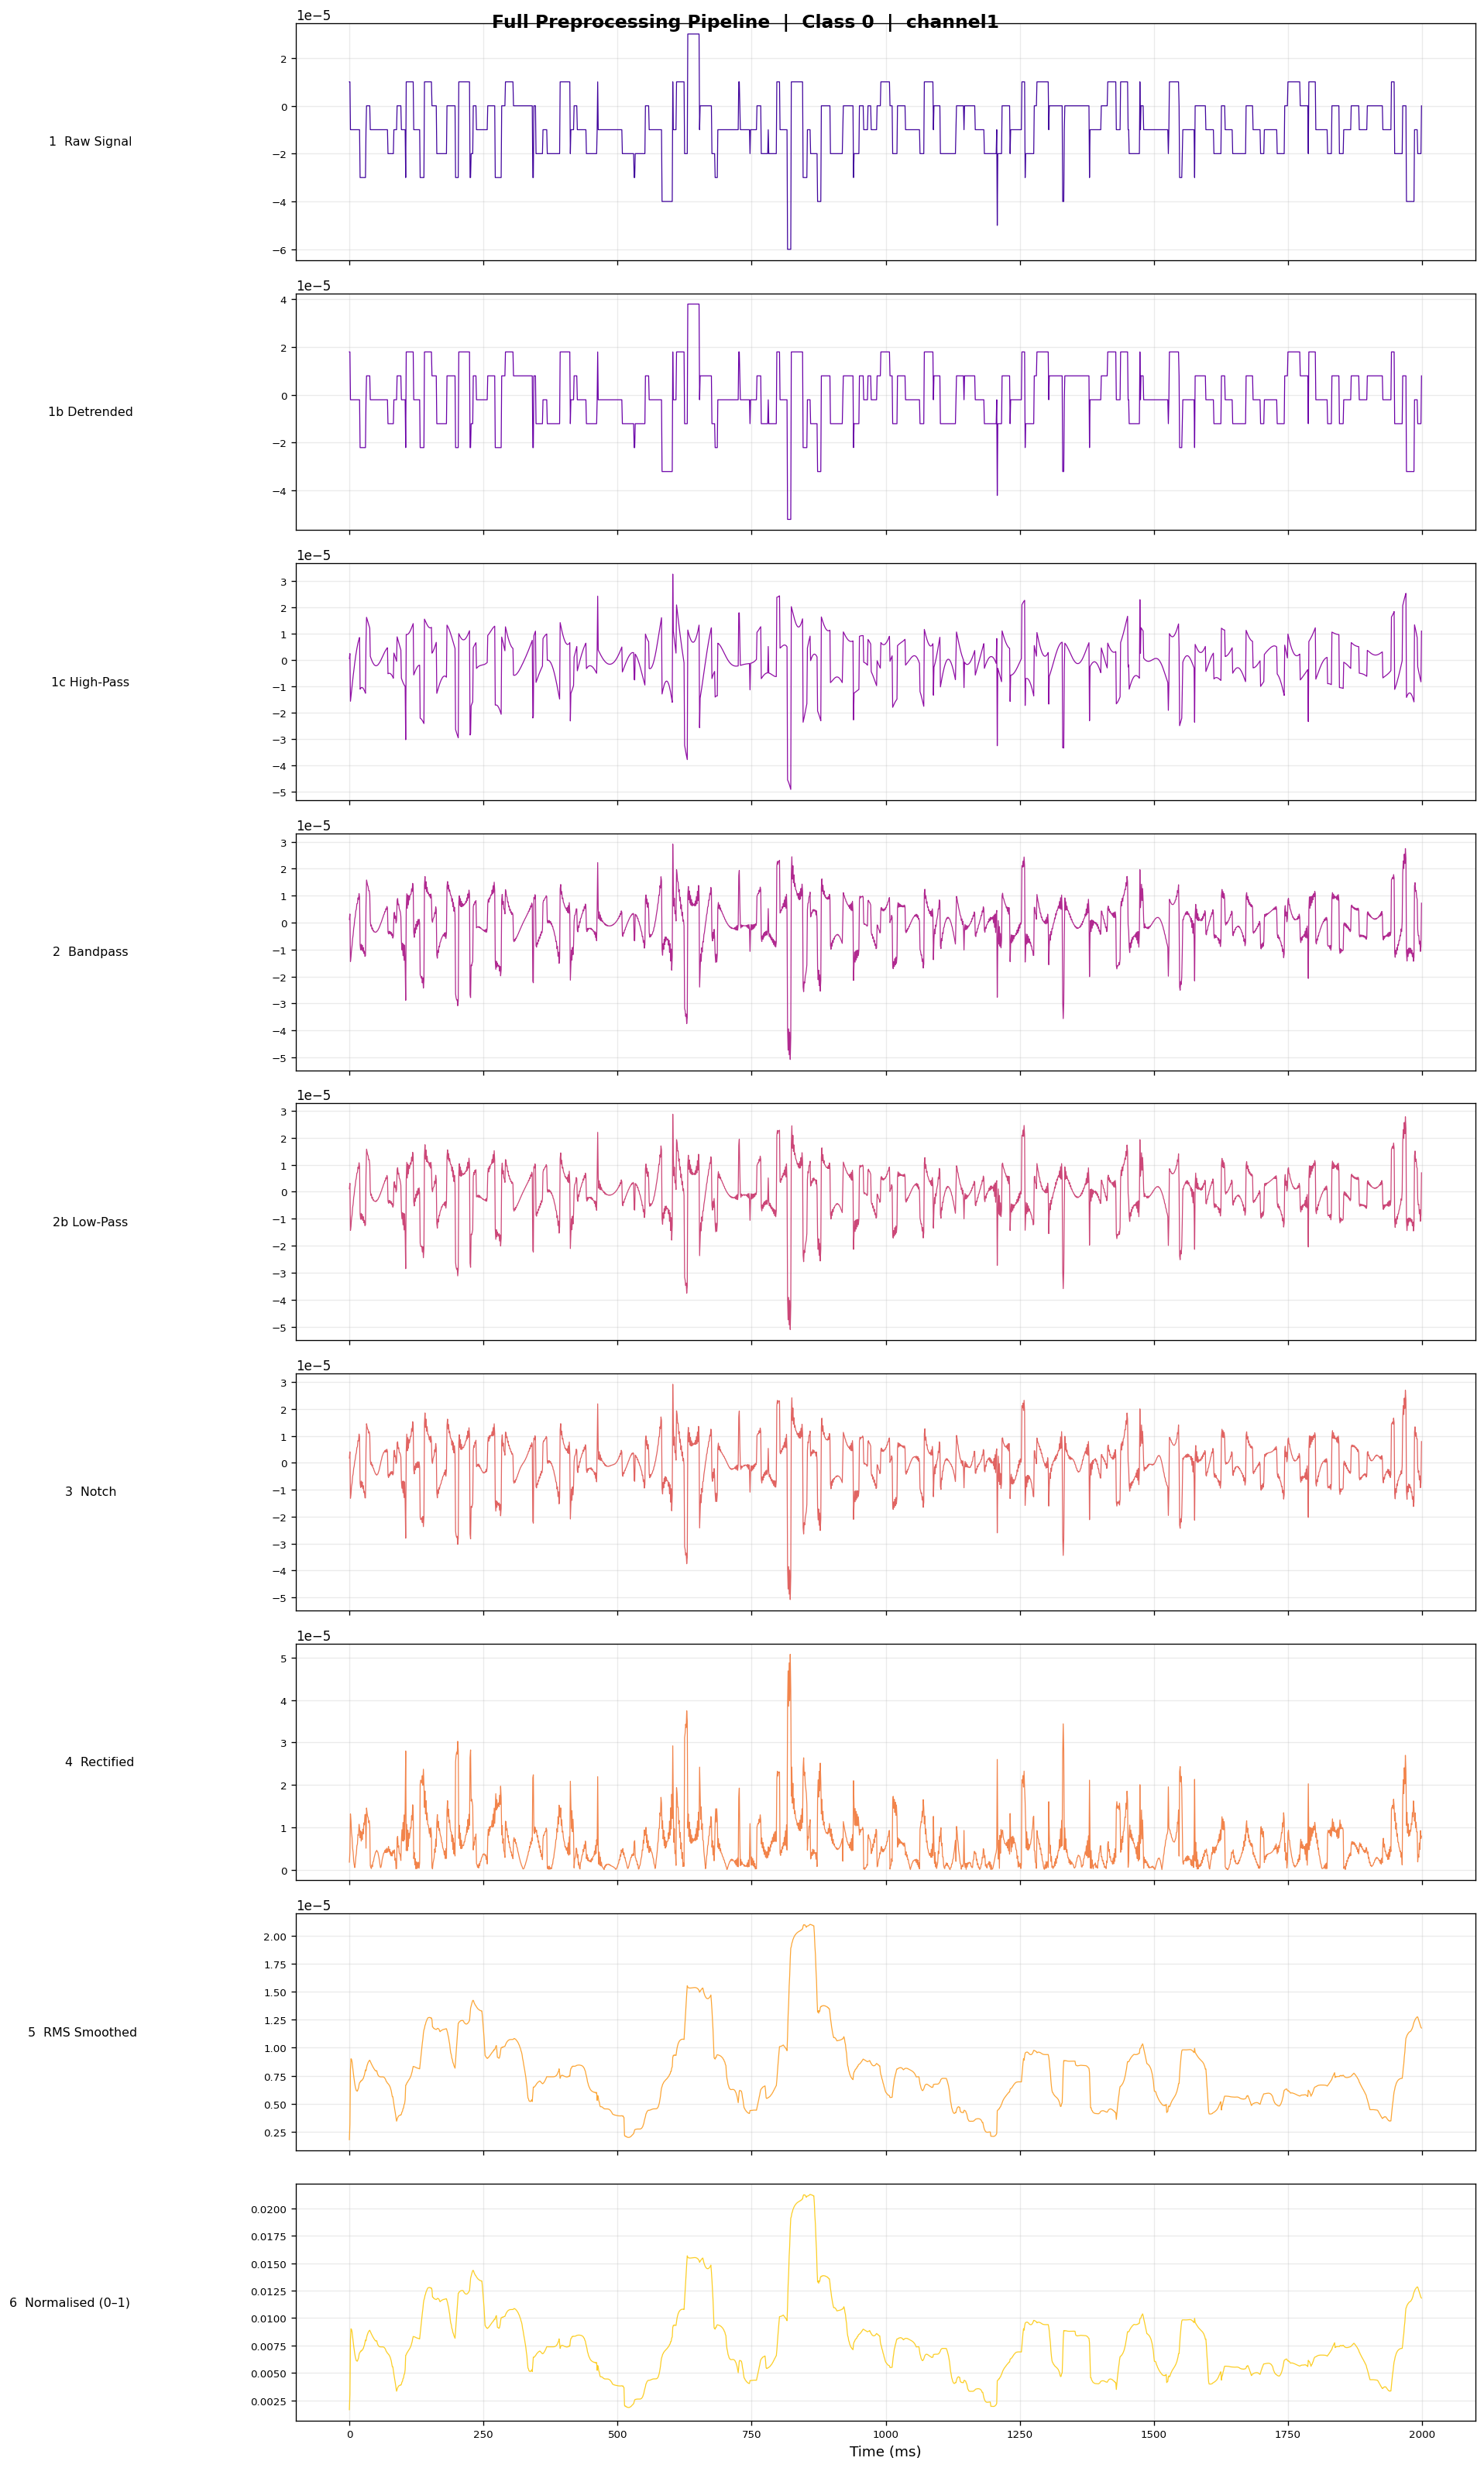


 PIPELINE COMPLETE
 Full normalised dataset shape : (4237907, 8)
 Segments for class 0          : 135 × (200 samples × 8 channels)


In [34]:
stages = {
    "1  Raw Signal":        vis_raw,
    "1b Detrended":         vis_detrended,
    "1c High-Pass":          vis_hp,
    "2  Bandpass":          vis_bp,
    "2b Low-Pass":           vis_lp,
    "3  Notch":             vis_notch,
    "4  Rectified":         vis_rect,
    "5  RMS Smoothed":      vis_rms,
    "6  Normalised (0–1)":  vis_norm,
}

n = min(VIS_SAMPLES, vis_raw.shape[0])
t = np.arange(n) / FS * 1000
n_ax = len(stages)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_ax))

fig, axes = plt.subplots(n_ax, 1, figsize=(16, 3 * n_ax), sharex=True)
fig.suptitle(
    f"Full Preprocessing Pipeline  |  Class {SELECTED_CLASS}  |  {CH_NAME}",
    fontsize=14, fontweight="bold"
)

for ax, (label, sig), color in zip(axes, stages.items(), colors):
    ax.plot(t, sig[:n, SELECTED_CH_IDX], color=color, linewidth=0.75)
    ax.set_ylabel(label, fontsize=9.5, rotation=0,
                  labelpad=140, va="center")
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel("Time (ms)", fontsize=11)
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n PIPELINE COMPLETE")
print(f" Full normalised dataset shape : {all_norm.shape}")
print(f" Segments for class {SELECTED_CLASS}          : {len(segments)} × "
      f"({SEG_SIZE} samples × {len(CHANNEL_COLS)} channels)")